In [1]:
!pip install yfinance pandas numpy wbdata tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: cachetools
    Found existing installation: cachetools 6.2.6
    Uninstalling cachetools-6.2.6:
      Successfully uninstalled cachetools-6.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [1]:
import pandas as pd

# S&P 500 companies (auto fetch)
sp500_url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
sp500 = pd.read_html(sp500_url, storage_options=headers)[0]

# Take first 150 tickers
tickers = sp500['Symbol'].tolist()[:300]

# Fix tickers like BRK.B → BRK-B for yfinance
tickers = [t.replace(".", "-") for t in tickers]

print("Total tickers:", len(tickers))

Total tickers: 300


In [44]:
import yfinance as yf
import numpy as np
from tqdm import tqdm

def get_financials(ticker):
    try:
        stock = yf.Ticker(ticker)

        income = stock.financials.T
        balance = stock.balance_sheet.T
        cashflow = stock.cashflow.T

        if income.empty or balance.empty or cashflow.empty:
            return pd.DataFrame()

        df = income.join(balance, how='inner', rsuffix='_bal')
        df = df.join(cashflow, how='inner', rsuffix='_cf')

        df['Ticker'] = ticker
        df['Year'] = df.index.year

        return df.reset_index(drop=True)

    except Exception as e:
        print(f"Error: {ticker}")
        return pd.DataFrame()

In [45]:
all_data = []

for t in tqdm(tickers):
    df = get_financials(t)
    if not df.empty:
        all_data.append(df)

data = pd.concat(all_data, ignore_index=True)

print("Raw shape:", data.shape)

100%|██████████| 300/300 [03:20<00:00,  1.49it/s]


Raw shape: (1411, 335)


In [46]:
data.head()

,Tax Effect Of Unusual Items,Tax Rate For Calcs,Normalized EBITDA,Total Unusual Items,Total Unusual Items Excluding Goodwill,Net Income From Continuing Operation Net Minority Interest,Reconciled Depreciation,Reconciled Cost Of Revenue,EBITDA,EBIT,...,Net Income From Tax Loss Carryforward,Net Income Extraordinary,Cash Flowsfromusedin Operating Activities Direct,Classesof Cash Payments,Other Cash Paymentsfrom Operating Activities,Paymentson Behalfof Employees,Classesof Cash Receiptsfrom Operating Activities,Other Cash Receiptsfrom Operating Activities,Dividend Paid Cfo,Securities Amortization
0,5.713743e+07,0.238073,6.227000e+09,2.400000e+08,2.400000e+08,3.250000e+09,1.308000e+09,1.499100e+10,6.467000e+09,5.159000e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.609371e+08,0.166840,5.809000e+09,1.564000e+09,1.564000e+09,4.009000e+09,1.363000e+09,1.444700e+10,7.373000e+09,6.010000e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9.144000e+06,0.254000,-8.379000e+09,3.600000e+07,3.600000e+07,-8.402000e+09,1.987000e+09,1.498300e+10,-8.343000e+09,-1.033000e+10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.103850e+08,0.045000,4.044000e+09,2.453000e+09,2.453000e+09,4.013000e+09,1.831000e+09,1.585300e+10,6.497000e+09,4.666000e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
print("Shape:", data.shape)
print("\nTop missing columns:")
print(data.isna().sum().sort_values(ascending=False).head(20))

Shape: (1411, 335)

Top missing columns:
Securities Amortization                                                 1410
Other Cash Receiptsfrom Operating Activities                            1410
Classesof Cash Receiptsfrom Operating Activities                        1410
Paymentson Behalfof Employees                                           1410
Other Cash Paymentsfrom Operating Activities                            1410
Cash Flowsfromusedin Operating Activities Direct                        1410
Classesof Cash Payments                                                 1410
Dividend Paid Cfo                                                       1409
Duefrom Related Parties Non Current                                     1409
Interest Paid Cfo                                                       1409
Depletion Income Statement                                              1409
Net Income From Tax Loss Carryforward                                   1408
Current Deferred Taxes Assets      

In [48]:
# Clean column names
data.columns = [col.replace(" ", "_") for col in data.columns]

# Ensure 'Tax_Rate' exists, prioritizing 'Tax_Rate_For_Calcs'
if 'Tax_Rate_For_Calcs' in data.columns:
    data = data.rename(columns={'Tax_Rate_For_Calcs': 'Tax_Rate'})

# Now 'Tax_Rate' either exists (from rename) or it doesn't.
# If it doesn't exist, create it with default. If it exists, fill NaNs.
#if 'Tax_Rate' not in data.columns:
   # data['Tax_Rate'] = 0.21 # Create with default
#else:
  #  data['Tax_Rate'] = data['Tax_Rate'].fillna(0.21) # Fill NaNs if it exists

# Key fields (handle missing safely)
data['EBIT'] = data.get('Operating_Income', np.nan)

# Tax_Rate is now guaranteed to be a single column and filled.
data['NOPAT'] = data['EBIT'] * (1 - data['Tax_Rate'])

data['Depreciation'] = data.get('Depreciation', 0)
data['CapEx'] = data.get('Capital_Expenditures', 0)

# Working Capital
data['Current_Assets'] = data.get('Total_Current_Assets', 0)
data['Current_Liabilities'] = data.get('Total_Current_Liabilities', 0)

data['WC'] = data['Current_Assets'] - data['Current_Liabilities']
data['dWC'] = data.groupby('Ticker')['WC'].diff()

# FCFF
data['FCFF'] = data['NOPAT'] + data['Depreciation'] - data['CapEx'] - data['dWC']

In [49]:
data.shape

(1411, 340)

In [50]:
def get_market_data(ticker):
    stock = yf.Ticker(ticker)
    info = stock.info

    return {
        "Ticker": ticker,
        "MarketCap": info.get("marketCap"),
        "SharesOutstanding": info.get("sharesOutstanding"),
        "Price": info.get("currentPrice"),
        "Beta": info.get("beta")
    }

market_data = pd.DataFrame([get_market_data(t) for t in tickers])

# Merge
data = data.merge(market_data, on="Ticker", how="left")

In [51]:
data.shape

(1411, 344)

In [52]:
import wbdata
import datetime

indicators = {
    "NY.GDP.MKTP.KD.ZG": "GDP_Growth",
    "FP.CPI.TOTL.ZG": "Inflation",
    "FR.INR.RINR": "Interest_Rate",
    "SL.UEM.TOTL.ZS": "Unemployment"
}

wb_data = wbdata.get_dataframe(indicators, country="USA")
wb_data = wb_data.reset_index()

wb_data['Year'] = wb_data['date'].astype(int)
wb_data = wb_data.drop(columns=['date'])

# Merge macro
data = data.merge(wb_data, on='Year', how='left')

print("✅ Macro data merged")

✅ Macro data merged


In [53]:
# Constants (you can improve later)
RISK_FREE_RATE = 0.07     # India 10Y approx
MARKET_RETURN = 0.12      # Expected market return

data['Risk_Free_Rate'] = RISK_FREE_RATE
data['Market_Return'] = MARKET_RETURN

In [54]:
data.shape

(1411, 350)

In [55]:
# Drop rows with missing key values
data = data.dropna(subset=['Total_Revenue', 'EBIT', 'FCFF'])

# Fill remaining NA
data = data.fillna(0)

print(data.shape)
data.head()

(449, 350)


,Tax_Effect_Of_Unusual_Items,Tax_Rate,Normalized_EBITDA,Total_Unusual_Items,Total_Unusual_Items_Excluding_Goodwill,Net_Income_From_Continuing_Operation_Net_Minority_Interest,Reconciled_Depreciation,Reconciled_Cost_Of_Revenue,EBITDA,EBIT,...,MarketCap,SharesOutstanding,Price,Beta,GDP_Growth,Inflation,Interest_Rate,Unemployment,Risk_Free_Rate,Market_Return
10,5.670000e+06,0.210000,1.076300e+10,2.700000e+07,2.700000e+07,1.340200e+10,3.218000e+09,1.736600e+10,1.079000e+10,6.825000e+09,...,158355046400,1737674869,91.13,0.782,2.793001,2.949525,0.0,4.022,0.07,0.12
11,-5.781000e+06,0.141000,1.058500e+10,-4.100000e+07,-4.100000e+07,5.723000e+09,3.243000e+09,1.669800e+10,1.054400e+10,6.478000e+09,...,158355046400,1737674869,91.13,0.782,2.887556,4.116338,0.0,3.638,0.07,0.12
12,-3.306044e+05,0.165302,1.213300e+10,-2.000000e+06,-2.000000e+06,6.933000e+09,3.267000e+09,1.788800e+10,1.213100e+10,8.362000e+09,...,158355046400,1737674869,91.13,0.782,2.512375,8.002800,0.0,3.650,0.07,0.12
15,-5.833800e+08,0.210000,1.768800e+10,-2.778000e+09,-2.778000e+09,4.278000e+09,8.386000e+09,1.690400e+10,1.491000e+10,1.189400e+10,...,351470780416,1768762377,198.71,0.364,2.793001,2.949525,0.0,4.022,0.07,0.12
16,-2.032800e+08,0.220000,1.809600e+10,-9.240000e+08,-9.240000e+08,4.863000e+09,8.698000e+09,2.041500e+10,1.717200e+10,1.353500e+10,...,351470780416,1768762377,198.71,0.364,2.887556,4.116338,0.0,3.638,0.07,0.12


In [56]:
data = data.rename(columns={
    'Total_Revenue': 'Revenue',
    'Depreciation_And_Amortization': 'Depreciation_Amortization',
    'Cash_And_Cash_Equivalents': 'Cash',
    'Diluted_Average_Shares': 'Shares_Outstanding',
    'dWC': 'Delta_Working_Capital'
})

In [57]:
data['Enterprise_Value'] = (
    data['MarketCap']
    + data['Total_Debt']
    - data['Cash']
)

In [58]:
data['PE_Ratio'] = data['MarketCap'] / data['Net_Income']

data['EV_EBITDA'] = data['Enterprise_Value'] / data['EBITDA']

data['EV_Sales'] = data['Enterprise_Value'] / data['Revenue']

In [59]:
# Example mapping (you should improve this)
industry_map = {
    'AAPL': 'Tech',
    'MSFT': 'Tech',
    'WMT': 'Retail'
}

data['Industry'] = data['Ticker'].map(industry_map)

In [60]:
final_cols = [
    'Ticker','Year',

    'Revenue','EBIT','EBITDA','Net_Income',
    'Tax_Rate','Depreciation_Amortization',
    'CapEx','Current_Assets','Current_Liabilities',
    'Total_Debt','Cash','Interest_Expense',

    'NOPAT','Delta_Working_Capital','FCFF',

    'Price','MarketCap','Shares_Outstanding',
    'Beta','Risk_Free_Rate','Market_Return',

    'GDP_Growth','Inflation','Interest_Rate','Unemployment',

    'Enterprise_Value','PE_Ratio','EV_EBITDA','EV_Sales','Industry'
]

# Keep only available
final_cols_available = [col for col in final_cols if col in data.columns]

data_model = data[final_cols_available]

print("✅ Final Dataset Ready:", data_model.shape)
data_model.head()

✅ Final Dataset Ready: (449, 32)


,Ticker,Year,Revenue,EBIT,EBITDA,Net_Income,Tax_Rate,Depreciation_Amortization,CapEx,Current_Assets,...,Market_Return,GDP_Growth,Inflation,Interest_Rate,Unemployment,Enterprise_Value,PE_Ratio,EV_EBITDA,EV_Sales,Industry
10,ABT,2024,4.195000e+10,6.825000e+09,1.079000e+10,1.340200e+10,0.210000,3.218000e+09,0,0,...,0.12,2.793001,2.949525,0.0,4.022,1.657600e+11,11.815777,15.362377,3.951372,NaN
11,ABT,2023,4.010900e+10,6.478000e+09,1.054400e+10,5.723000e+09,0.141000,3.243000e+09,0,0,...,0.12,2.887556,4.116338,0.0,3.638,1.670870e+11,27.669936,15.846647,4.165824,NaN
12,ABT,2022,4.365300e+10,8.362000e+09,1.213100e+10,6.933000e+09,0.165302,3.267000e+09,0,0,...,0.12,2.512375,8.002800,0.0,3.650,1.661890e+11,22.840768,13.699534,3.807048,NaN
15,ABBV,2024,5.633400e+10,1.189400e+10,1.491000e+10,4.278000e+09,0.210000,8.386000e+09,0,0,...,0.12,2.793001,2.949525,0.0,4.022,4.130908e+11,82.157733,27.705619,7.332886,NaN
16,ABBV,2023,5.431800e+10,1.353500e+10,1.717200e+10,4.863000e+09,0.220000,8.698000e+09,0,0,...,0.12,2.887556,4.116338,0.0,3.638,3.980418e+11,72.274477,23.179698,7.327990,NaN


In [61]:
data_model['Cost_of_Equity'] = (
    data_model['Risk_Free_Rate']
    + data_model['Beta'] * (data_model['Market_Return'] - data_model['Risk_Free_Rate'])
)

/tmp/ipykernel_6088/1056307410.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model['Cost_of_Equity'] = (


In [62]:
data_model['Cost_of_Debt'] = (
    data_model['Interest_Expense'] / data_model['Total_Debt']
)

# Handle division issues
data_model['Cost_of_Debt'] = data_model['Cost_of_Debt'].replace([np.inf, -np.inf], np.nan)
data_model['Cost_of_Debt'] = data_model['Cost_of_Debt'].fillna(0.05)  # fallback

/tmp/ipykernel_6088/895841790.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model['Cost_of_Debt'] = (
/tmp/ipykernel_6088/895841790.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model['Cost_of_Debt'] = data_model['Cost_of_Debt'].replace([np.inf, -np.inf], np.nan)
/tmp/ipykernel_6088/895841790.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

In [63]:
data_model['Total_Value'] = data_model['MarketCap'] + data_model['Total_Debt']

data_model['Equity_Weight'] = data_model['MarketCap'] / data_model['Total_Value']
data_model['Debt_Weight'] = data_model['Total_Debt'] / data_model['Total_Value']

/tmp/ipykernel_6088/1244993410.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model['Total_Value'] = data_model['MarketCap'] + data_model['Total_Debt']
/tmp/ipykernel_6088/1244993410.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model['Equity_Weight'] = data_model['MarketCap'] / data_model['Total_Value']
/tmp/ipykernel_6088/1244993410.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


In [64]:
data_model['WACC'] = (
    data_model['Equity_Weight'] * data_model['Cost_of_Equity']
    + data_model['Debt_Weight'] * data_model['Cost_of_Debt'] * (1 - data_model['Tax_Rate'])
)

/tmp/ipykernel_6088/4266088621.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model['WACC'] = (


In [65]:
data_model['Revenue_Growth'] = data_model.groupby('Ticker')['Revenue'].pct_change()
data_model['Revenue_Growth'] = data_model['Revenue_Growth'].fillna(0.05)

/tmp/ipykernel_6088/1751176833.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model['Revenue_Growth'] = data_model.groupby('Ticker')['Revenue'].pct_change()
/tmp/ipykernel_6088/1751176833.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model['Revenue_Growth'] = data_model['Revenue_Growth'].fillna(0.05)


In [66]:
forecast_years = 5

fcff_forecasts = []

for ticker in data_model['Ticker'].unique():
    df = data_model[data_model['Ticker'] == ticker].sort_values('Year')

    last_fcff = df['FCFF'].iloc[-1]
    growth = df['Revenue_Growth'].mean()

    forecasts = []
    for t in range(1, forecast_years + 1):
        future_fcff = last_fcff * ((1 + growth) ** t)
        forecasts.append(future_fcff)

    fcff_forecasts.append({
        'Ticker': ticker,
        'FCFF_Forecasts': forecasts
    })

fcff_df = pd.DataFrame(fcff_forecasts)

In [67]:
def dcf_valuation(row, forecasts):
    wacc = row['WACC']
    g = 0.03  # terminal growth

    # Discount FCFF
    pv_fcff = sum([
        fcff / ((1 + wacc) ** (i+1))
        for i, fcff in enumerate(forecasts)
    ])

    # Terminal Value
    terminal_value = forecasts[-1] * (1 + g) / (wacc - g)

    pv_terminal = terminal_value / ((1 + wacc) ** len(forecasts))

    enterprise_value = pv_fcff + pv_terminal

    equity_value = enterprise_value - row['Total_Debt'] + row['Cash']

    intrinsic_price = equity_value / row['Shares_Outstanding']

    return enterprise_value, equity_value, intrinsic_price

In [68]:
results = []

for _, row in data_model.groupby('Ticker').tail(1).iterrows():

    ticker = row['Ticker']

    forecasts = fcff_df[fcff_df['Ticker'] == ticker]['FCFF_Forecasts'].values

    if len(forecasts) == 0:
        continue

    forecasts = forecasts[0]

    ev, eq, price = dcf_valuation(row, forecasts)

    results.append({
        'Ticker': ticker,
        'Enterprise_Value_DCF': ev,
        'Equity_Value_DCF': eq,
        'Intrinsic_Price': price,
        'Market_Price': row['Price']
    })

valuation_df = pd.DataFrame(results)

In [69]:
valuation_df['Upside_%'] = (
    (valuation_df['Intrinsic_Price'] - valuation_df['Market_Price'])
    / valuation_df['Market_Price']
) * 100

In [70]:
valuation_df.head()

,Ticker,Enterprise_Value_DCF,Equity_Value_DCF,Intrinsic_Price,Market_Price,Upside_%
0,ABT,9.860360e+10,9.076960e+10,51.456688,91.13,-43.534854
1,ABBV,2.093611e+11,1.552911e+11,87.340329,198.71,-56.046334
2,ACN,7.606526e+10,8.062933e+10,125.426914,178.36,-29.677666
3,ADBE,4.815265e+10,4.775565e+10,101.392028,245.44,-58.689689
4,AMD,1.515833e+10,1.713033e+10,10.904094,347.81,-96.864928


# Deterministic DCF to an AI-powered valuation system

In [71]:
import numpy as np

df = data_model.copy()

# Profitability
df['EBITDA_Margin'] = df['EBITDA'] / df['Revenue']
df['Net_Margin'] = df['Net_Income'] / df['Revenue']

# Efficiency
df['ROIC'] = df['NOPAT'] / (df['Total_Debt'] + df['MarketCap'])

# Leverage
df['Debt_to_Equity'] = df['Total_Debt'] / df['MarketCap']

# Growth
df['Revenue_Growth'] = df.groupby('Ticker')['Revenue'].pct_change()

df = df.fillna(0)

/tmp/ipykernel_6088/257199809.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


In [72]:
!pip install xgboost shap

In [73]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

features = [
    'Revenue','EBIT','EBITDA',
    'EBITDA_Margin','Net_Margin',
    'ROIC','Debt_to_Equity',
    'Revenue_Growth',
    'GDP_Growth','Inflation'
]

X = df[features]
y = df['FCFF']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBRegressor(n_estimators=200, max_depth=5)
model.fit(X_train, y_train)

print("✅ Model trained")

✅ Model trained


In [74]:
df['Predicted_FCFF'] = model.predict(X)

In [75]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

fcff_series = df[['FCFF']].values
fcff_scaled = scaler.fit_transform(fcff_series)

X_lstm, y_lstm = [], []

window = 3

for i in range(len(fcff_scaled) - window):
    X_lstm.append(fcff_scaled[i:i+window])
    y_lstm.append(fcff_scaled[i+window])

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

model_lstm = Sequential([
    LSTM(50, return_sequences=False),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_lstm, y_lstm, epochs=10, batch_size=16)

print("✅ LSTM trained")

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0089
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0077
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0072
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0069
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0068
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0068
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0065
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0065
Epoch 9/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0063
Epoch 10/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0063
✅ LSTM trained


In [76]:
last_seq = fcff_scaled[-window:]
last_seq = last_seq.reshape(1, window, 1)

future_fcff_scaled = model_lstm.predict(last_seq)
future_fcff = scaler.inverse_transform(future_fcff_scaled)

print("Forecast FCFF:", future_fcff)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
Forecast FCFF: [[1.2409952e+09]]


In [77]:
import numpy as np

def monte_carlo_dcf(row, fcff, simulations=1000):

    results = []

    for _ in range(simulations):
        wacc = np.random.normal(row['WACC'], 0.01)
        g = np.random.normal(0.03, 0.01)

        ev = fcff * (1 + g) / (wacc - g)
        eq = ev - row['Total_Debt'] + row['Cash']
        price = eq / row['Shares_Outstanding']

        results.append(price)

    return np.mean(results), np.std(results)

In [78]:
mc_results = []

for _, row in df.groupby('Ticker').tail(1).iterrows():

    mean_price, risk = monte_carlo_dcf(row, row['Predicted_FCFF'])

    mc_results.append({
        'Ticker': row['Ticker'],
        'AI_Price': mean_price,
        'Risk': risk,
        'Market_Price': row['Price']
    })

mc_df = pd.DataFrame(mc_results)

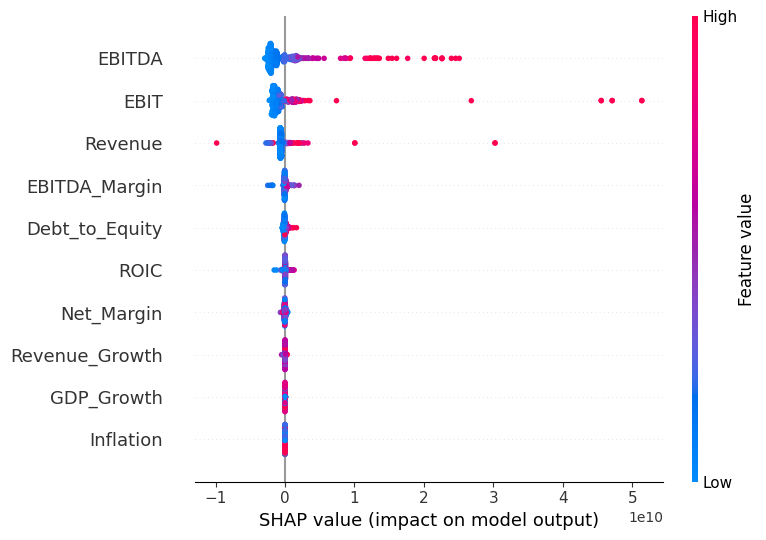

In [79]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

In [80]:
mc_df['Upside_%'] = (
    (mc_df['AI_Price'] - mc_df['Market_Price']) /
    mc_df['Market_Price']
) * 100

mc_df = mc_df.sort_values('Upside_%', ascending=False)

mc_df.to_excel('AI_Valuation_Output.xlsx', index=False)

mc_df.head()

,Ticker,AI_Price,Risk,Market_Price,Upside_%
98,FISV,915.946863,10905.321101,60.84,1405.501090
145,KHC,307.107652,4523.112922,21.94,1299.761402
112,GM,936.921525,6108.709566,78.05,1100.411947
41,CPB,187.928214,1559.114611,20.62,811.388039
38,BXP,427.520903,4618.613467,57.73,640.552405


# repeated code

In [ ]:
import pandas as pd

# S&P 500 companies (auto fetch)
sp500_url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
sp500 = pd.read_html(sp500_url, storage_options=headers)[0]

# Take first 150 tickers
tickers = sp500['Symbol'].tolist()[:300]

# Fix tickers like BRK.B → BRK-B for yfinance
tickers = [t.replace(".", "-") for t in tickers]

print("Total tickers:", len(tickers))

Total tickers: 300


In [ ]:
import yfinance as yf
import numpy as np
from tqdm import tqdm

def get_financials(ticker):
    try:
        stock = yf.Ticker(ticker)

        income = stock.financials.T
        balance = stock.balance_sheet.T
        cashflow = stock.cashflow.T

        if income.empty or balance.empty or cashflow.empty:
            return pd.DataFrame()

        df = income.join(balance, how='inner', rsuffix='_bal')
        df = df.join(cashflow, how='inner', rsuffix='_cf')

        df['Ticker'] = ticker
        df['Year'] = df.index.year

        return df.reset_index(drop=True)

    except Exception as e:
        print(f"Error: {ticker}")
        return pd.DataFrame()

In [ ]:
all_data = []

for t in tqdm(tickers):
    df = get_financials(t)
    if not df.empty:
        all_data.append(df)

data = pd.concat(all_data, ignore_index=True)

print("Raw shape:", data.shape)

100%|██████████| 300/300 [03:12<00:00,  1.56it/s]


Raw shape: (1411, 335)


In [ ]:
# Clean column names
data.columns = [col.replace(" ", "_") for col in data.columns]

# Revenue fix
if 'Total_Revenue' not in data.columns:
    if 'Revenue' in data.columns:
        data['Total_Revenue'] = data['Revenue']

# EBIT (robust)
data['EBIT'] = data.get('Operating_Income')

# fallback
data['EBIT'] = data['EBIT'].fillna(data.get('EBITDA', 0) * 0.8)

In [ ]:
# Defaults
tax_rate = 0.21

data['Depreciation'] = data.get('Depreciation', 0)
data['CapEx'] = data.get('Capital_Expenditures', 0)

# Working Capital
data['WC'] = (
    data.get('Total_Current_Assets', 0)
    - data.get('Total_Current_Liabilities', 0)
)

data['dWC'] = data.groupby('Ticker')['WC'].diff().fillna(0)

# NOPAT
data['NOPAT'] = data['EBIT'] * (1 - tax_rate)

# FCFF
data['FCFF'] = (
    data['NOPAT']
    + data['Depreciation']
    - data['CapEx']
    - data['dWC']
)

/tmp/ipykernel_2344/2972485793.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['CapEx'] = data.get('Capital_Expenditures', 0)
/tmp/ipykernel_2344/2972485793.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['WC'] = (
/tmp/ipykernel_2344/2972485793.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = 

In [ ]:
def get_market_data(ticker):
    try:
        info = yf.Ticker(ticker).info
        return {
            "Ticker": ticker,
            "MarketCap": info.get("marketCap", np.nan),
            "Price": info.get("currentPrice", np.nan),
            "Beta": info.get("beta", np.nan)
        }
    except:
        return {
            "Ticker": ticker,
            "MarketCap": np.nan,
            "Price": np.nan,
            "Beta": np.nan
        }

market_data = pd.DataFrame([get_market_data(t) for t in tickers])

data = data.merge(market_data, on="Ticker", how="left")

In [ ]:
data.shape

(1411, 343)

In [ ]:
# Only require EBIT (minimum viable)
data = data.dropna(subset=['EBIT'])

# Fill rest
data = data.fillna(0)

print("Final shape:", data.shape)

Final shape: (1076, 343)


In [ ]:
data.head()

,Tax_Effect_Of_Unusual_Items,Tax_Rate_For_Calcs,Normalized_EBITDA,Total_Unusual_Items,Total_Unusual_Items_Excluding_Goodwill,Net_Income_From_Continuing_Operation_Net_Minority_Interest,Reconciled_Depreciation,Reconciled_Cost_Of_Revenue,EBITDA,EBIT,...,Dividend_Paid_Cfo,Securities_Amortization,CapEx,WC,dWC,NOPAT,FCFF,MarketCap,Price,Beta
0,5.713743e+07,0.238073,6.227000e+09,2.400000e+08,2.400000e+08,3.250000e+09,1.308000e+09,1.499100e+10,6.467000e+09,4.791000e+09,...,0.0,0.0,0,0,0.0,3.784890e+09,0.0,76143607808,145.99,1.158
1,2.609371e+08,0.166840,5.809000e+09,1.564000e+09,1.564000e+09,4.009000e+09,1.363000e+09,1.444700e+10,7.373000e+09,4.822000e+09,...,0.0,0.0,0,0,0.0,3.809380e+09,0.0,76143607808,145.99,1.158
2,9.144000e+06,0.254000,-8.379000e+09,3.600000e+07,3.600000e+07,-8.402000e+09,1.987000e+09,1.498300e+10,-8.343000e+09,-1.072500e+10,...,0.0,0.0,0,0,0.0,-8.472750e+09,0.0,76143607808,145.99,1.158
3,1.103850e+08,0.045000,4.044000e+09,2.453000e+09,2.453000e+09,4.013000e+09,1.831000e+09,1.585300e+10,6.497000e+09,1.916000e+09,...,0.0,0.0,0,0,0.0,1.513640e+09,0.0,76143607808,145.99,1.158
5,0.000000e+00,0.236000,8.137000e+08,0.000000e+00,0.000000e+00,5.462000e+08,8.510000e+07,2.342800e+09,8.137000e+08,7.280000e+08,...,0.0,0.0,0,0,0.0,5.751200e+08,0.0,8899878912,64.38,1.346


In [ ]:
data.to_csv("valuation_dataset_150_companies.csv", index=False)

In [ ]:
# Rename columns to standard format
data = data.rename(columns={
    'Total_Revenue': 'Revenue',
    'Tax_Rate_For_Calcs': 'Tax_Rate',
    'Depreciation_And_Amortization': 'Depreciation_Amortization',
    'Cash_And_Cash_Equivalents': 'Cash',
    'Diluted_Average_Shares': 'Shares_Outstanding',
    'dWC': 'Delta_Working_Capital'

SyntaxError: incomplete input (1373304757.py, line 8)

In [ ]:
final_cols = [
    # Identity
    'Ticker','Year',

    # Financials
    'Revenue','EBIT','EBITDA','Net_Income',
    'Tax_Rate','Depreciation_Amortization',
    'CapEx','Current_Assets','Current_Liabilities',
    'Total_Debt','Cash','Interest_Expense',

    # Derived
    'NOPAT','Delta_Working_Capital','FCFF',

    # Market
    'Price','MarketCap','Shares_Outstanding',
    'Beta','Risk_Free_Rate','Market_Return',

    # Macro
    'GDP_Growth','Inflation','Interest_Rate','Unemployment',

    # Comps
    'Enterprise_Value','PE_Ratio','EV_EBITDA','EV_Sales','Industry'
]

In [ ]:
final_cols = [
    'Ticker','Year',
    'Total_Revenue','EBIT','EBITDA',
    'NOPAT','FCFF',
    'MarketCap','Price','Beta'
]

data_model = data[final_cols]

print(data_model.head())

  Ticker  Year  Total_Revenue          EBIT        EBITDA         NOPAT  FCFF  \
0    MMM  2025   2.494800e+10  4.791000e+09  6.467000e+09  3.784890e+09   0.0   
1    MMM  2024   2.457500e+10  4.822000e+09  7.373000e+09  3.809380e+09   0.0   
2    MMM  2023   2.461000e+10 -1.072500e+10 -8.343000e+09 -8.472750e+09   0.0   
3    MMM  2022   2.616100e+10  1.916000e+09  6.497000e+09  1.513640e+09   0.0   
5    AOS  2025   3.830200e+09  7.280000e+08  8.137000e+08  5.751200e+08   0.0   

     MarketCap   Price   Beta  
0  76143607808  145.99  1.158  
1  76143607808  145.99  1.158  
2  76143607808  145.99  1.158  
3  76143607808  145.99  1.158  
5   8899878912   64.38  1.346  


In [ ]:
data_model.to_csv("valuation_dataset_150_companies.csv", index=False)

In [13]:
import wbdata
import datetime
import pandas as pd

indicators = {
    "NY.GDP.MKTP.KD.ZG": "gdp_growth",
    "FP.CPI.TOTL.ZG": "inflation",
    "SL.UEM.TOTL.ZS": "unemployment"
}

wb_data = wbdata.get_dataframe(indicators, country="USA")
wb_data = wb_data.reset_index()
wb_data['date'] = pd.to_datetime(wb_data['date'])
wb_data['Year'] = wb_data['date'].dt.year

# Merge macro
data = data.merge(wb_data[['Year','gdp_growth','inflation','unemployment']],
                  on='Year', how='left')